# AROME Daily Fetch — France Metropolitan Grid

Self-healing archive: queries the API for all available coverages,
compares against the local cache, downloads only what's missing.

Two modes:
- **Static** (daily cron): 00Z run, first 24h → analysis-quality daily archive
- **Dynamic** (every 3h): latest window → rolling near-real-time

Run this notebook (or the `sync()` function) any time — it catches up
automatically. If you missed 3 days, next run fetches all 3.

```
data/arome_daily/
  static/arome_daily_2026-07-15.nc    ← full 24h, analysis quality
  dynamic/arome_daily_2026-07-15.nc   ← assembled from 3h windows
```

In [1]:
import logging
import os
import re
import time
from collections import defaultdict
from datetime import date, datetime, timedelta, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import xarray as xr

REPO_ROOT = os.path.dirname(os.getcwd())
os.chdir(REPO_ROOT)

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(message)s")
logger = logging.getLogger("arome")

from irrigator.utils.auth_meteofrance import meteo_headers

In [2]:
# === Configuration ===

FRANCE_BBOX = {"north": 51.5, "south": 41.0, "west": -6.0, "east": 10.0}

RAW_DIR = Path("data/raw/arome")
DAILY_DIR = Path("data/processed/arome")
for d in [RAW_DIR / "static", RAW_DIR / "dynamic", RAW_DIR / "forecast" , DAILY_DIR / "static", DAILY_DIR / "dynamic", DAILY_DIR / "forecast"]:
    d.mkdir(parents=True, exist_ok=True)

DELETE_RAW = False
API_PAUSE = 0.5

BASE_URL = "https://public-api.meteofrance.fr/public/arome/1.0"
WCS_RESOURCE = "wcs/MF-NWP-HIGHRES-AROME-001-FRANCE-WCS"

FORECAST_HORIZON = 48

---
## Step 0: Discover available coverages from the API

In [3]:
def get_available_coverages() -> list[str]:
    """Query GetCapabilities and return all available coverage IDs."""
    resp = requests.get(
        f"{BASE_URL}/{WCS_RESOURCE}/GetCapabilities",
        params={"service": "WCS", "version": "2.0.1", "language": "eng"},
        headers=meteo_headers(),
        timeout=60,
    )
    resp.raise_for_status()
    
    coverages = []
    for line in resp.text.splitlines():
        if "CoverageId" in line:
            cid = line.strip().replace("<wcs:CoverageId>", "").replace("</wcs:CoverageId>", "")
            if cid:
                coverages.append(cid)
    return coverages


def parse_coverage_id(cid: str) -> dict | None:
    """Extract variable, run datetime, and accumulation from a coverage ID.
    
    Examples:
      TOTAL_PRECIPITATION__GROUND_OR_WATER_SURFACE___2026-06-10T00.00.00Z_PT1H
      TEMPERATURE__GROUND_OR_WATER_SURFACE___2026-06-10T00.00.00Z
    """
    # Split on the triple underscore that separates variable from datetime
    parts = cid.split("___")
    if len(parts) != 2:
        return None
    
    variable = parts[0]
    datetime_part = parts[1]  # e.g., "2026-06-10T00.00.00Z_PT1H" or "2026-06-10T00.00.00Z"
    
    # Split accumulation if present
    accum = None
    # Match: date part then optional _P... accumulation
    m = re.match(r"(\d{4}-\d{2}-\d{2}T\d{2}\.\d{2}\.\d{2}Z)(?:_(P.+))?", datetime_part)
    if not m:
        return None
    
    dt_str = m.group(1)
    accum = m.group(2)  # None if no accumulation
    
    dt = datetime.strptime(dt_str, "%Y-%m-%dT%H.%M.%SZ").replace(tzinfo=timezone.utc)
    
    return {
        "coverage_id": cid,
        "variable": variable,
        "run_datetime": dt,
        "run_date": dt.date(),
        "run_hour": dt.hour,
        "accumulation": accum,
    }

In [4]:
# Fetch and parse
raw_coverages = get_available_coverages()
parsed = [parse_coverage_id(c) for c in raw_coverages]
parsed = [p for p in parsed if p is not None]

# Index by variable
by_variable = defaultdict(list)
for p in parsed:
    by_variable[p["variable"]].append(p)

print(f"Total coverages: {len(parsed)}")
print(f"Unique variables: {len(by_variable)}")
print()
for var, items in sorted(by_variable.items()):
    dates = sorted(set(p["run_date"] for p in items))
    accums = sorted(set(p["accumulation"] or "instant" for p in items))
    print(f"  {var[:60]:60s} dates={dates[0]}→{dates[-1]}  accum={accums}")

Total coverages: 6105
Unique variables: 46

  AVERAGE_LIGHTNING_STRIKE_DENSITY_OVER_3HOURS__GROUND_OR_WATE dates=2026-06-11→2026-06-15  accum=['instant']
  BRIGHTNESS_TEMPERATURE__GROUND_OR_WATER_SURFACE              dates=2026-06-11→2026-06-15  accum=['instant']
  CONVECTIVE_AVAILABLE_POTENTIAL_ENERGY__GROUND_OR_WATER_SURFA dates=2026-06-11→2026-06-15  accum=['instant']
  CONVECTIVE_INHIBITION__GROUND_OR_WATER_SURFACE               dates=2026-06-11→2026-06-15  accum=['instant']
  DEW_POINT_TEMPERATURE__SPECIFIC_HEIGHT_LEVEL_ABOVE_GROUND    dates=2026-06-11→2026-06-15  accum=['instant']
  DOWNWARD_DIRECT_SHORT_WAVE_RADIATION_FLUX__GROUND_OR_WATER_S dates=2026-06-11→2026-06-15  accum=['P1D', 'P2D', 'PT12H', 'PT18H', 'PT1H', 'PT3H', 'PT6H', 'PT9H']
  DOWNWARD_LONG_WAVE_RADIATION_FLUX__GROUND_OR_WATER_SURFACE   dates=2026-06-11→2026-06-15  accum=['P1D', 'P2D', 'PT12H', 'PT18H', 'PT1H', 'PT3H', 'PT6H', 'PT9H']
  DOWNWARD_SHORT_WAVE_RADIATION_FLUX__GROUND_OR_WATER_SURFACE  dates=2026-06-11→

---
## Variable mapping and fetch logic

In [5]:
# Map our short names to API coverage base names
VARS_INSTANTANEOUS = {
    "temp_2m": {
        "coverage": "TEMPERATURE__GROUND_OR_WATER_SURFACE",
        "height": None,
        "static_hours": list(range(0, 24)),   # all 24 for Tmin/Tmax
        "dynamic_hours": [0, 1, 2],                  # single snapshot per window
    },
    "wind_10m": {
        "coverage": "WIND_SPEED__SPECIFIC_HEIGHT_LEVEL_ABOVE_GROUND",
        "height": "10",
        "static_hours": list(range(0, 24)), # 3-hourly for daily mean
        "dynamic_hours": [0, 1, 2],
    },
    "dewpoint_2m": {
        "coverage": "DEW_POINT_TEMPERATURE__SPECIFIC_HEIGHT_LEVEL_ABOVE_GROUND",
        "height": "2",
        "static_hours": list(range(0, 24)),
        "dynamic_hours": [0, 1, 2],
    },
}

VARS_ACCUMULATED = {
    "precip": {
        "coverage": "TOTAL_PRECIPITATION__GROUND_OR_WATER_SURFACE",
        "static_accum": "P1D",     # 1 call, full day total
        "dynamic_accum": "PT3H",   # 1 call per 3h window
    },
    "solar_rad": {
        "coverage": "DOWNWARD_SHORT_WAVE_RADIATION_FLUX__GROUND_OR_WATER_SURFACE",
        "static_accum": "P1D",
        "dynamic_accum": "PT3H",
    },
}


def find_available_run_dates(
    parsed_coverages: list[dict],
    run_hour: int = 0,
) -> list[date]:
    """Extract unique run dates for a specific run hour from capabilities."""
    dates = set()
    for p in parsed_coverages:
        if p["run_hour"] == run_hour:
            dates.add(p["run_date"])
    return sorted(dates)


available_00z_dates = find_available_run_dates(parsed, run_hour=0)
print(f"Available 00Z dates: {available_00z_dates[0]} → {available_00z_dates[-1]} ({len(available_00z_dates)} days)")

Available 00Z dates: 2026-06-11 → 2026-06-15 (5 days)


---
## Core fetch: single timestep

In [6]:
def fetch_single_timestep(
    coverage_id: str,
    valid_time_utc: datetime,
    out_path: Path,
    bbox: dict = FRANCE_BBOX,
    height: str | None = None,
    overwrite: bool = False,
) -> Path:
    """Fetch one AROME grid for one timestep."""
    if out_path.exists() and not overwrite:
        return out_path

    session = requests.Session()
    session.headers.update(meteo_headers())

    time_str = valid_time_utc.strftime("%Y-%m-%dT%H:%M:%SZ")
    params = {
        "service": "WCS",
        "version": "2.0.1",
        "request": "GetCoverage",
        "coverageId": coverage_id,
        "subset": [
            f"time({time_str})",
            f"lat({bbox['south']},{bbox['north']})",
            f"long({bbox['west']},{bbox['east']})",
        ],
        "format": "application/wmo-grib",
    }
    if height:
        params["subset"].append(f"height({height})")

    resp = session.get(f"{BASE_URL}/{WCS_RESOURCE}/GetCoverage", params=params, timeout=120)
    if not resp.ok:
        logger.error("FAIL %s at %s: %d", coverage_id[:50], time_str, resp.status_code)
        resp.raise_for_status()

    out_path.parent.mkdir(parents=True, exist_ok=True)
    out_path.write_bytes(resp.content)
    return out_path

---
## Static fetch for one date

In [ ]:
def format_cid(
    coverage_base: str,
    run_date: date,
    run_hour: int = 0,  # ← new parameter
    accum: str | None = None,
) -> str:
    dt_str = f"{run_date.isoformat()}T{run_hour:02d}.00.00Z"
    cid = f"{coverage_base}___{dt_str}"
    if accum:
        cid += f"_{accum}"
    return cid


def fetch_static_day(target_date: date, overwrite: bool = False) -> Path:
    """Fetch all variables for one day from the 00Z run (static mode).
    
    ~42 API calls: precip(1) + rad(1) + temp(24) + wind(8) + dew(8)
    """
    day_dir = RAW_DIR / "static" / target_date.isoformat()
    run_start = datetime(target_date.year, target_date.month, target_date.day, tzinfo=timezone.utc)
    calls = 0

    # Accumulated: P1D, valid at step 24h
    for var_name, cfg in VARS_ACCUMULATED.items():
        cid = format_cid(cfg["coverage"], target_date, cfg["static_accum"])
        valid_t = run_start + timedelta(hours=24)
        out = day_dir / f"{var_name}_P1D.grib2"
        fetch_single_timestep(cid, valid_t, out, height=None, overwrite=overwrite)
        calls += 1
        time.sleep(API_PAUSE)

    # Instantaneous: per hour or per 3h
    for var_name, cfg in VARS_INSTANTANEOUS.items():
        cid = format_cid(cfg["coverage"], target_date)
        for h in cfg["static_hours"]:
            valid_t = run_start + timedelta(hours=h)
            out = day_dir / f"{var_name}_{h:02d}.grib2"
            fetch_single_timestep(cid, valid_t, out, height=cfg["height"], overwrite=overwrite)
            calls += 1
            time.sleep(API_PAUSE)

    logger.info("[static] %s: %d calls", target_date, calls)
    return day_dir

## Static fetch for Forecast

In [8]:
def fetch_forecast_day(target_date: date, overwrite: bool = False) -> Path:
    """Fetch all variables for 48 hours from the 00Z run (static mode).

    ~42 API calls: precip(1) + rad(1) + temp(24) + wind(8) + dew(8)
    """
    day_dir = RAW_DIR / "forecast" / target_date.isoformat()
    run_start = datetime(target_date.year, target_date.month, target_date.day, tzinfo=timezone.utc)
    calls = 0

    # Accumulated: P1D, valid at step 24h
    for var_name, cfg in VARS_ACCUMULATED.items():
        cid = format_cid(cfg["coverage"], target_date, cfg["static_accum"])
        for day in [1,2]:
            valid_t = run_start + timedelta(hours=24*day)
            out = day_dir / f"{var_name}_day{day}_P1D.grib2"
            fetch_single_timestep(cid, valid_t, out, height=None, overwrite=overwrite)
        calls += 1
        time.sleep(API_PAUSE)

    # Instantaneous: per hour or per 3h
    for var_name, cfg in VARS_INSTANTANEOUS.items():
        cid = format_cid(cfg["coverage"], target_date)
        for day in [1,2]:
            for h in cfg["static_hours"]:
                valid_t = run_start + timedelta(hours=h) + timedelta(hours=24*(day-1))
                out = day_dir / f"{var_name}_day{day}_{h:02d}.grib2"
                fetch_single_timestep(cid, valid_t, out, height=cfg["height"], overwrite=overwrite)
                calls += 1
                time.sleep(API_PAUSE)

    logger.info("[forecast] %s: %d calls", target_date, calls)
    return day_dir


---
## Dynamic fetch for one 3h window

In [ ]:
def fetch_dynamic_window(
    run_date: date,
    run_hour: int,
    forecast_hour: int,
    overwrite: bool = False,
) -> Path:
    """Fetch one 3h window (5 API calls)."""
    run_start = datetime(run_date.year, run_date.month, run_date.day,
                         run_hour, tzinfo=timezone.utc)
    valid_t = run_start + timedelta(hours=forecast_hour)
    tag = valid_t.strftime("%Y-%m-%dT%H")
    window_dir = RAW_DIR / "dynamic" / tag

    for var_name, cfg in VARS_ACCUMULATED.items():
        cid = format_cid(cfg["coverage"], run_date,run_hour, cfg["dynamic_accum"])
        out = window_dir / f"{var_name}_PT3H.grib2"
        fetch_single_timestep(cid, valid_t + timedelta(hours=3), out, overwrite=overwrite)
        time.sleep(API_PAUSE)

    for var_name, cfg in VARS_INSTANTANEOUS.items():
        cid = format_cid(cfg["coverage"], run_date, run_hour)
        for h in cfg["dynamic_hours"]:
            valid_t_sub = valid_t + timedelta(hours=h)
            out = window_dir / f"{var_name}_{h:02d}.grib2"
            fetch_single_timestep(cid, valid_t_sub, out, height=cfg["height"], overwrite=overwrite)
            time.sleep(API_PAUSE)

    logger.info("[dynamic] %s: done", tag)
    return window_dir

---
## Build daily NetCDF from raw GRIBs

In [10]:
from irrigator.ingestion.meteofrance_client import open_forecast


def _open_grib_scalar(path: Path,*, is_surface : bool = False) -> xr.DataArray:
    ds = open_forecast(path)
    ds = ds.drop_vars(["surface"]) if is_surface else ds.drop_vars(["heightAboveGround"])
    #ds = ds.rename({"surface": "heightAboveGround"}) if is_surface else ds
    return ds[list(ds.data_vars)[0]]


def build_daily(target_date: date, mode: str = "static") -> Path:
    """Build daily NetCDF from raw GRIBs."""
    out_path = DAILY_DIR / mode / f"arome_daily_{target_date.isoformat()}.nc"
    if mode == "static":
        return _build_static(target_date, out_path)
    elif mode == "dynamic":
        return _build_dynamic(target_date, out_path)
    elif mode == "forecast":
        return _build_forecast(target_date, out_path)
    else:
        raise NotImplementedError


def _build_static(target_date: date, out_path: Path) -> Path:
    day_dir = RAW_DIR / "static" / target_date.isoformat()
    if not day_dir.exists():
        raise FileNotFoundError(f"No static raw for {target_date}")

    daily = {}

    # Accumulated: single P1D file = daily total
    pf = day_dir / "precip_P1D.grib2"
    if pf.exists():
        daily["precip_mm"] = _open_grib_scalar(pf, is_surface=True)  # kg/m² = mm
    
    rf = day_dir / "solar_rad_P1D.grib2"
    if rf.exists():
        daily["rs_mj"] = _open_grib_scalar(rf, is_surface=True) / 1e6  # J → MJ

    # Temperature: hourly → min/max/mean
    temp_files = sorted(day_dir.glob("temp_2m_*.grib2"))
    if temp_files:
        temps = xr.concat([_open_grib_scalar(f, is_surface=True) for f in temp_files], dim="step")
        daily["t_min"] = temps.min(dim="step") - 273.15
        daily["t_max"] = temps.max(dim="step") - 273.15
        daily["t_mean"] = temps.mean(dim="step") - 273.15

    # Wind: 3-hourly → mean
    wind_files = sorted(day_dir.glob("wind_10m_*.grib2"))
    if wind_files:
        daily["wind_speed_10m"] = xr.concat(
            [_open_grib_scalar(f) for f in wind_files], dim="step"
        ).mean(dim="step")

    # Dewpoint: 3-hourly → mean, K → °C
    dew_files = sorted(day_dir.glob("dewpoint_2m_*.grib2"))
    if dew_files:
        daily["dewpoint"] = xr.concat(
            [_open_grib_scalar(f) for f in dew_files], dim="step"
        ).mean(dim="step") - 273.

    ds = xr.Dataset(
        {k: v.expand_dims(valid_time=[np.datetime64(target_date)]) for k, v in daily.items()}
    )
    ds.attrs["source"] = f"AROME 00Z {target_date} (static)"
    encoding = {v: {"zlib": True, "complevel": 4} for v in ds.data_vars}
    ds.to_netcdf(out_path, encoding=encoding)
    logger.info("[static] %s → %.1f MB", out_path.name, out_path.stat().st_size / 1e6)
    
    return out_path


def _build_dynamic(target_date: date, out_path: Path) -> Path:
    pattern = f"{target_date.isoformat()}T*"
    window_dirs = sorted((RAW_DIR / "dynamic").glob(pattern))
    
    if not window_dirs:
        raise FileNotFoundError(f"No dynamic windows for {target_date}")

    daily = {}
    # Accumulated: sum 3h windows
    precip_parts = [
        _open_grib_scalar(wd / "precip_PT3H.grib2", is_surface=True)
        for wd in window_dirs
        if (wd / "precip_PT3H.grib2").exists()
    ]
    
    if precip_parts:
        daily["precip_mm"] = sum(precip_parts)
    
    rad_parts = [
        _open_grib_scalar(wd / "solar_rad_PT3H.grib2", is_surface=True)
        for wd in window_dirs
        if (wd / "solar_rad_PT3H.grib2").exists()
    ]
    if rad_parts:
        daily["rs_mj"] = sum(rad_parts) / 1e6
    # Instantaneous: aggregate across windows
    def _collect(name, is_surface):
        return [
            _open_grib_scalar(path, is_surface=is_surface)
            for wd in window_dirs
            for path in sorted(wd.glob(f"{name}_*.grib2"))
        ]
    tv = _collect("temp_2m", is_surface=True)
    if tv:
        t = xr.concat(tv, dim="step")
        daily["t_min"] = t.min(dim="step") - 273.15
        daily["t_max"] = t.max(dim="step") - 273.15
        daily["t_mean"] = t.mean(dim="step") - 273.15
    wv = _collect("wind_10m", is_surface=False)
    if wv:
        daily["wind_speed_10m"] = xr.concat(wv, dim="step").mean(dim="step")

    dv = _collect("dewpoint_2m", is_surface=False)
    if dv:
        daily["dewpoint"] = xr.concat(dv, dim="step").mean(dim="step") - 273.15

    n_win = len(window_dirs)

    ds = xr.Dataset(
        {k: v.expand_dims(valid_time=[np.datetime64(target_date)]) for k, v in daily.items()}
    )
    ds.attrs["source"] = f"AROME dynamic {target_date} ({n_win} windows)"
    ds.attrs["n_windows"] = n_win
    ds.attrs["complete"] = int(n_win >= 8)
    encoding = {v: {"zlib": True, "complevel": 4} for v in ds.data_vars}
    ds.to_netcdf(out_path, encoding=encoding)
    logger.info("[dynamic] %s → %d windows, %.1f MB", out_path.name, n_win, out_path.stat().st_size / 1e6)
    return out_path


def _build_forecast(target_date: date, out_path: Path) -> Path:
    day_dir = RAW_DIR / "forecast" / target_date.isoformat()
    if not day_dir.exists():
        raise FileNotFoundError(f"No forecast raw data for {target_date}")

    days_forecast = [1, 2]
    daily: dict[str, xr.DataArray] = {}

    def _merge_ds(parts: list[xr.DataArray]) -> xr.DataArray:
        """Promote scalar valid_time coordinates and concatenate them."""
        expanded = [
            part if "valid_time" in part.dims else part.expand_dims("valid_time", axis=-1) for part in parts
        ]

        return xr.concat(
            expanded,
            dim="valid_time",
            join="exact",
            coords="minimal",
            compat="override",
        ).sortby("valid_time")

    # Accumulated precipitation: one P1D file per forecast day
    precip_files = [day_dir / f"precip_day{day}_P1D.grib2" for day in days_forecast]

    if all(path.exists() for path in precip_files):
        precip_parts = [_open_grib_scalar(path, is_surface=True) for path in precip_files]
        daily["precip_mm"] = _merge_ds(precip_parts)

    # Accumulated solar radiation: one P1D file per forecast day
    solar_files = [day_dir / f"solar_rad_day{day}_P1D.grib2" for day in days_forecast]

    if all(path.exists() for path in solar_files):
        solar_parts = [_open_grib_scalar(path, is_surface=True) / 1e6 for path in solar_files]
        daily["rs_mj"] = _merge_ds(solar_parts)

    sub_daily: list[dict[str, xr.DataArray]] = [{} for _ in days_forecast]

    for index, day in enumerate(days_forecast):
        # Temperature: hourly → daily min/max/mean
        temp_files = sorted(day_dir.glob(f"temp_2m_day{day}_*.grib2"))

        if temp_files:
            temps = xr.concat(
                [_open_grib_scalar(path, is_surface=True) for path in temp_files],
                dim="step",
            )

            sub_daily[index]["t_min"] = temps.min(dim="step") - 273.15
            sub_daily[index]["t_max"] = temps.max(dim="step") - 273.15
            sub_daily[index]["t_mean"] = temps.mean(dim="step") - 273.15

        # Wind: 3-hourly → daily mean
        wind_files = sorted(day_dir.glob(f"wind_10m_day{day}_*.grib2"))

        if wind_files:
            winds = xr.concat(
                [_open_grib_scalar(path) for path in wind_files],
                dim="step",
            )
            sub_daily[index]["wind_speed_10m"] = winds.mean(dim="step")

        # Dewpoint: 3-hourly → daily mean, K → °C
        dew_files = sorted(day_dir.glob(f"dewpoint_2m_day{day}_*.grib2"))

        if dew_files:
            dewpoints = xr.concat(
                [_open_grib_scalar(path) for path in dew_files],
                dim="step",
            )
            sub_daily[index]["dewpoint"] = dewpoints.mean(dim="step") - 273.15

    # Convert each day's sub-daily aggregates into a Dataset with a
    # length-one valid_time dimension.
    sub_daily_datasets: list[xr.Dataset] = []

    for day, variables in zip(days_forecast, sub_daily):
        if not variables:
            continue

        # Remove scalar/auxiliary valid_time coordinates left by GRIB files.
        # The daily aggregate receives one explicit valid_time below.
        cleaned_variables = {}

        for name, array in variables.items():
            if "valid_time" in array.coords:
                array = array.drop_vars("valid_time")

            if "step" in array.coords and "step" not in array.dims:
                array = array.drop_vars("step")

            cleaned_variables[name] = array

        valid_time = np.datetime64(target_date + timedelta(days=day))

        day_dataset = xr.Dataset(cleaned_variables).expand_dims(valid_time=[valid_time], axis=-1).transpose("valid_time", "latitude", "longitude", ...)

        sub_daily_datasets.append(day_dataset)

    # Dataset containing precipitation and radiation.
    daily_dataset = xr.Dataset(daily).transpose("valid_time", "latitude", "longitude", ...)

    daily_dataset = daily_dataset.assign_coords(
        valid_time=daily_dataset.valid_time.astype("datetime64[s]")
    )



    datasets_to_merge = [daily_dataset]

    if sub_daily_datasets:
        sub_daily_dataset = xr.concat(
            sub_daily_datasets,
            dim="valid_time",
            join="exact",
            coords="minimal",
            compat="override",
        ).sortby("valid_time")

        sub_daily_dataset = sub_daily_dataset.assign_coords(
            valid_time=sub_daily_dataset.valid_time.astype("datetime64[s]")
        )

        datasets_to_merge.append(sub_daily_dataset)

    # Merge all variables on the common valid_time/lat/lon coordinates.
    ds = xr.merge(
        datasets_to_merge,
        join="exact",
        compat="no_conflicts",
    ).sortby("valid_time")

    ds.attrs["source"] = f"AROME 00Z {target_date}"

    encoding = {variable: {"zlib": True, "complevel": 4} for variable in ds.data_vars}

    ds.to_netcdf(out_path, encoding=encoding)

    logger.info(
        "[forecast] %s → %.1f MB",
        out_path.name,
        out_path.stat().st_size / 1e6,
    )

    return out_path

---
## Sync: discover available → compare cache → fetch missing

In [11]:
def sync_static(overwrite: bool = False, delete_raw : bool = DELETE_RAW) -> dict:
    """Discover all available 00Z dates, fetch and build any missing.
    
    Self-healing: run any time, catches up automatically.
    Returns {date: status} for each available date.
    """
    logger.info("Syncing static archive...")
    all_coverages = get_available_coverages()
    parsed_all = [parse_coverage_id(c) for c in all_coverages]
    parsed_all = [p for p in parsed_all if p is not None]
    available_dates = find_available_run_dates(parsed_all, run_hour=0)
    
    results = {}
    
    for d in available_dates:
        cache_path = DAILY_DIR / "static" / f"arome_daily_{d.isoformat()}.nc"
        
        if cache_path.exists() and not overwrite:
            results[d] = "cached"
            continue
        
        try:
            fetch_static_day(d, overwrite=overwrite)
            build_daily(d, mode="static")
            
            # Clean raw
            if delete_raw:
                import shutil
                raw_dir = RAW_DIR / "static" / d.isoformat()
                if raw_dir.exists():
                    shutil.rmtree(raw_dir)
            
            results[d] = "fetched"
        except Exception as e:
            logger.error("[static] %s FAILED: %s", d, e)
            results[d] = f"error: {e}"
    
    n_cached = sum(1 for v in results.values() if v == "cached")
    n_fetched = sum(1 for v in results.values() if v == "fetched")
    n_errors = sum(1 for v in results.values() if v.startswith("error"))
    
    logger.info(
        "Sync complete: %d available, %d cached, %d fetched, %d errors",
        len(results), n_cached, n_fetched, n_errors,
    )
    return results


def sync_dynamic(overwrite: bool = False, fill : bool = True) -> dict:
    """Discover all available run times, fetch missing 3h windows.
    """
    logger.info("Syncing dynamic archive...")
    all_coverages = get_available_coverages()
    parsed_all = [parse_coverage_id(c) for c in all_coverages]
    parsed_all = [p for p in parsed_all if p is not None]
    
    # Group by run date + run hour
    runs = set()
    for p in parsed_all:
        runs.add((p["run_date"], p["run_hour"]))
    
    results = {}
    
    for run_date, run_hour in sorted(runs):
        # For each run, fetch short-range windows (0, 3, 6h ahead)
        run_start = datetime(run_date.year, run_date.month, run_date.day,
                                run_hour, tzinfo=timezone.utc)
        valid_t = run_start #+ timedelta(hours=fh)
        tag = valid_t.strftime("%Y-%m-%dT%H")
        window_dir = RAW_DIR / "dynamic" / tag
        
        # Check if we already have all files for this window
        expected_files = len(VARS_ACCUMULATED) + len(VARS_INSTANTANEOUS)
        existing = len(list(window_dir.glob("*.grib2"))) if window_dir.exists() else 0
        
        if existing >= expected_files: # temp fix with -1 because of solar_rad
            results[tag] = "cached"
            continue
        
        try:
            fetch_dynamic_window(run_date, run_hour, 0, overwrite=overwrite) # replaced fh by 0
            results[tag] = "fetched"
        except Exception as e:
            results[tag] = f"error: {e}"
    
    # Build daily archives from all windows
    available_days = set()
    for tag in results:
        d = date.fromisoformat(tag[:10])
        available_days.add(d)
    
    for d in sorted(available_days):
        try:
            build_daily(d, mode="dynamic")
        except Exception as e:
            logger.error("[dynamic] build %s failed: %s", d, e)
    
    return results


def sync_forecast(overwrite: bool = False, delete_raw : bool = DELETE_RAW) -> dict:
    """Discover all available 00Z dates, fetch and build any missing.
    
    Self-healing: run any time, catches up automatically.
    Returns {date: status} for each available date.
    """
    logger.info("Syncing static archive...")
    all_coverages = get_available_coverages()
    parsed_all = [parse_coverage_id(c) for c in all_coverages]
    parsed_all = [p for p in parsed_all if p is not None]
    available_dates = find_available_run_dates(parsed_all, run_hour=0)
    results = {}
    
    for d in available_dates:
        cache_path = DAILY_DIR / "forecast" / f"arome_daily_{d.isoformat()}.nc"
        
        if cache_path.exists() and not overwrite:
            results[d] = "cached"
            continue
        
        try:
            fetch_forecast_day(d, overwrite=overwrite)
            build_daily(d, mode="forecast")
            
            # Clean raw
            if delete_raw:
                import shutil
                raw_dir = RAW_DIR / "forecast" / d.isoformat()
                if raw_dir.exists():
                    shutil.rmtree(raw_dir)
            
            results[d] = "fetched"
        except Exception as e:
            logger.error("[forecast] %s FAILED: %s", d, e)
            results[d] = f"error: {e}"
    
    n_cached = sum(1 for v in results.values() if v == "cached")
    n_fetched = sum(1 for v in results.values() if v == "fetched")
    n_errors = sum(1 for v in results.values() if v.startswith("error"))
    
    logger.info(
        "Sync complete: %d available, %d cached, %d fetched, %d errors",
        len(results), n_cached, n_fetched, n_errors,
    )
    return results

## Run static archive

In [ ]:
# === RUN STATIC SYNC ===
# Discovers all available 00Z dates, downloads missing ones, builds daily archives.

results = sync_static(overwrite=False)

for d, status in sorted(results.items()):
    marker = "✓" if status == "cached" else ("↓" if status == "fetched" else "✗")
    print(f"  {marker} {d}: {status}")

2026-06-15 11:22:17,413 Syncing static archive...
2026-06-15 11:24:23,407 [static] 2026-06-15: 74 calls
2026-06-15 11:24:26,310 [static] arome_daily_2026-06-15.nc → 20.3 MB
2026-06-15 11:24:26,311 Sync complete: 5 available, 4 cached, 1 fetched, 0 errors


  ✓ 2026-06-11: cached
  ✓ 2026-06-12: cached
  ✓ 2026-06-13: cached
  ✓ 2026-06-14: cached
  ↓ 2026-06-15: fetched


## Run dynamic archive

In [13]:
# === RUN DYNAMIC SYNC (optional, for near-real-time) ===
results_dyn = sync_dynamic(overwrite=True)

# ISSUE WITH THE FH BEING 0,3,6 : I THINK IT'S GOOD WHEN NO NEW IS AVAILABLE, BUT THE ISSUE COMES BECAUSE ITS OVER CONSUMING API CALLS FOR OLDER DATA

2026-06-15 11:05:47,098 Syncing dynamic archive...
2026-06-15 11:05:51,017 [dynamic] arome_daily_2026-06-11.nc → 8 windows, 20.7 MB
2026-06-15 11:05:54,400 [dynamic] arome_daily_2026-06-12.nc → 8 windows, 20.3 MB
2026-06-15 11:05:57,661 [dynamic] arome_daily_2026-06-13.nc → 8 windows, 19.6 MB
2026-06-15 11:06:00,877 [dynamic] arome_daily_2026-06-14.nc → 8 windows, 19.9 MB
2026-06-15 11:06:02,282 [dynamic] arome_daily_2026-06-15.nc → 2 windows, 19.4 MB


## Run forecast archive (0-48h)

In [12]:
# === RUN STATIC SYNC ===
# Discovers all available 00Z dates, downloads missing ones, builds daily archives.

results = sync_forecast(overwrite=False)

for d, status in sorted(results.items()):
    marker = "✓" if status == "cached" else ("↓" if status == "fetched" else "✗")
    print(f"  {marker} {d}: {status}")


2026-06-15 19:35:44,786 Syncing static archive...
2026-06-15 19:36:58,352 [forecast] 2026-06-11: 146 calls
2026-06-15 19:37:07,324 [forecast] arome_daily_2026-06-11.nc → 40.5 MB
2026-06-15 19:39:07,483 [forecast] 2026-06-12: 146 calls
2026-06-15 19:39:13,523 [forecast] arome_daily_2026-06-12.nc → 39.4 MB
2026-06-15 19:42:47,817 [forecast] 2026-06-13: 146 calls
2026-06-15 19:42:53,696 [forecast] arome_daily_2026-06-13.nc → 39.3 MB
2026-06-15 19:46:32,305 [forecast] 2026-06-14: 146 calls
2026-06-15 19:46:38,225 [forecast] arome_daily_2026-06-14.nc → 40.0 MB
2026-06-15 19:50:09,004 [forecast] 2026-06-15: 146 calls
2026-06-15 19:50:14,881 [forecast] arome_daily_2026-06-15.nc → 40.7 MB
2026-06-15 19:50:14,886 Sync complete: 5 available, 0 cached, 5 fetched, 0 errors


  ↓ 2026-06-11: fetched
  ↓ 2026-06-12: fetched
  ↓ 2026-06-13: fetched
  ↓ 2026-06-14: fetched
  ↓ 2026-06-15: fetched


In [13]:
a = xr.open_dataset(
    "/home/mbaldacchino/code/IrriGator/data/processed/arome/forecast/arome_daily_2026-06-11.nc"
)

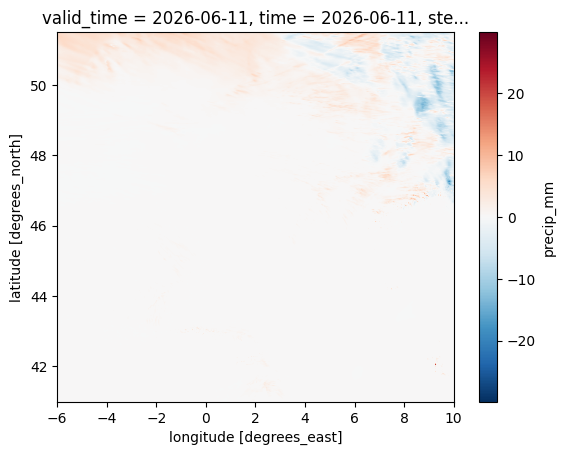

In [19]:
(b-a.isel(valid_time=1)).precip_mm.plot()

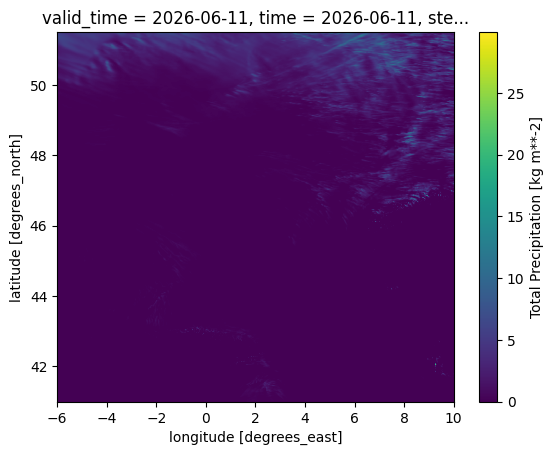

In [17]:
b = xr.open_dataset(
    "/home/mbaldacchino/code/IrriGator/data/processed/arome/static/arome_daily_2026-06-11.nc"
)
b.isel(valid_time=0).precip_mm.plot()

In [31]:
target_date = results[0]

day_dir = RAW_DIR / "forecast" / target_date.isoformat()
if not day_dir.exists():
    raise FileNotFoundError(f"No forecast raw data for {target_date}")

days_forecast = [1, 2]
daily: dict[str, xr.DataArray] = {}

def _merge_ds(parts: list[xr.DataArray]) -> xr.DataArray:
    """Promote scalar valid_time coordinates and concatenate them."""
    expanded = [
        part if "valid_time" in part.dims else part.expand_dims("valid_time", axis=-1) for part in parts
    ]

    return xr.concat(
        expanded,
        dim="valid_time",
        join="exact",
        coords="minimal",
        compat="override",
    ).sortby("valid_time")

# Accumulated precipitation: one P1D file per forecast day
precip_files = [day_dir / f"precip_day{day}_P1D.grib2" for day in days_forecast]

if all(path.exists() for path in precip_files):
    precip_parts = [_open_grib_scalar(path, is_surface=True) for path in precip_files]
    daily["precip_mm"] = _merge_ds(precip_parts)

# Accumulated solar radiation: one P1D file per forecast day
solar_files = [day_dir / f"solar_rad_day{day}_P1D.grib2" for day in days_forecast]

if all(path.exists() for path in solar_files):
    solar_parts = [_open_grib_scalar(path, is_surface=True) / 1e6 for path in solar_files]
    daily["rs_mj"] = _merge_ds(solar_parts)

sub_daily: list[dict[str, xr.DataArray]] = [{} for _ in days_forecast]

for index, day in enumerate(days_forecast):
    # Temperature: hourly → daily min/max/mean
    temp_files = sorted(day_dir.glob(f"temp_2m_day{day}_*.grib2"))

    if temp_files:
        temps = xr.concat(
            [_open_grib_scalar(path, is_surface=True) for path in temp_files],
            dim="step",
        )

        sub_daily[index]["t_min"] = temps.min(dim="step") - 273.15
        sub_daily[index]["t_max"] = temps.max(dim="step") - 273.15
        sub_daily[index]["t_mean"] = temps.mean(dim="step") - 273.15

    # Wind: 3-hourly → daily mean
    wind_files = sorted(day_dir.glob(f"wind_10m_day{day}_*.grib2"))

    if wind_files:
        winds = xr.concat(
            [_open_grib_scalar(path) for path in wind_files],
            dim="step",
        )
        sub_daily[index]["wind_speed_10m"] = winds.mean(dim="step")

    # Dewpoint: 3-hourly → daily mean, K → °C
    dew_files = sorted(day_dir.glob(f"dewpoint_2m_day{day}_*.grib2"))

    if dew_files:
        dewpoints = xr.concat(
            [_open_grib_scalar(path) for path in dew_files],
            dim="step",
        )
        sub_daily[index]["dewpoint"] = dewpoints.mean(dim="step") - 273.15

# Convert each day's sub-daily aggregates into a Dataset with a
# length-one valid_time dimension.
sub_daily_datasets: list[xr.Dataset] = []

for day, variables in zip(days_forecast, sub_daily):
    if not variables:
        continue

    # Remove scalar/auxiliary valid_time coordinates left by GRIB files.
    # The daily aggregate receives one explicit valid_time below.
    cleaned_variables = {}

    for name, array in variables.items():
        if "valid_time" in array.coords:
            array = array.drop_vars("valid_time")

        if "step" in array.coords and "step" not in array.dims:
            array = array.drop_vars("step")

        cleaned_variables[name] = array

    valid_time = np.datetime64(target_date + timedelta(days=day))

    day_dataset = xr.Dataset(cleaned_variables).expand_dims(valid_time=[valid_time], axis=-1).transpose("valid_time", "latitude", "longitude", ...)

    sub_daily_datasets.append(day_dataset)

# Dataset containing precipitation and radiation.
daily_dataset = xr.Dataset(daily).transpose("valid_time", "latitude", "longitude", ...)

daily_dataset = daily_dataset.assign_coords(
    valid_time=daily_dataset.valid_time.astype("datetime64[s]")
)



datasets_to_merge = [daily_dataset]

if sub_daily_datasets:
    sub_daily_dataset = xr.concat(
        sub_daily_datasets,
        dim="valid_time",
        join="exact",
        coords="minimal",
        compat="override",
    ).sortby("valid_time")

    sub_daily_dataset = sub_daily_dataset.assign_coords(
        valid_time=sub_daily_dataset.valid_time.astype("datetime64[s]")
    )

    datasets_to_merge.append(sub_daily_dataset)

# Merge all variables on the common valid_time/lat/lon coordinates.
ds = xr.merge(
    datasets_to_merge,
    join="exact",
    compat="no_conflicts",
).sortby("valid_time")

ds.attrs["source"] = f"AROME 00Z {target_date}"

encoding = {variable: {"zlib": True, "complevel": 4} for variable in ds.data_vars}

ds.to_netcdf(out_path, encoding=encoding)

logger.info(
    "[forecast] %s → %.1f MB",
    out_path.name,
    out_path.stat().st_size / 1e6,
)


NameError: name 'out_path' is not defined

In [30]:
print("daily:", daily_dataset.valid_time.values)
print("sub-daily:", sub_daily_dataset.valid_time.values)
print("daily dtype:", daily_dataset.valid_time.dtype)
print("sub-daily dtype:", sub_daily_dataset.valid_time.dtype)


daily: ['2026-06-12T00:00:00.000000000' '2026-06-13T00:00:00.000000000']
sub-daily: ['2026-06-12T00:00:00' '2026-06-13T00:00:00']
daily dtype: datetime64[ns]
sub-daily dtype: datetime64[s]


In [19]:
cleaned_variables


{'t_min': <xarray.DataArray 't' (latitude: 1051, longitude: 1601)> Size: 7MB
 array([[13.56955 , 13.563171, 13.562439, ...,  9.845367,  9.814117,
          9.923492],
        [13.56955 , 13.563171, 13.56015 , ..., 10.095367, 10.064117,
         10.048492],
        [13.563171, 13.563171, 13.563171, ..., 10.134735, 10.11911 ,
         10.05661 ],
        ...,
        [13.598572, 13.707947, 13.786072, ..., 20.9758  , 21.004822,
         21.058746],
        [13.739197, 13.848572, 13.879822, ..., 20.999939, 21.023193,
         21.094421],
        [13.957947, 13.989197, 14.020447, ..., 20.987335, 21.006989,
         21.047943]], shape=(1051, 1601), dtype=float32)
 Coordinates:
     time       datetime64[ns] 8B 2026-06-11
   * latitude   (latitude) float64 8kB 51.5 51.49 51.48 ... 41.02 41.01 41.0
   * longitude  (longitude) float64 13kB -6.0 -5.99 -5.98 ... 9.98 9.99 10.0,
 't_max': <xarray.DataArray 't' (latitude: 1051, longitude: 1601)> Size: 7MB
 array([[13.595367, 13.591736, 13.591736, .

---
## Cache loader for the pipeline

In [14]:
def load_arome_daily_cache(
    start_date: date,
    end_date: date,
) -> xr.Dataset:
    """Load cached AROME daily grids. Prefers static, falls back to dynamic."""
    files = []
    missing = []
    current = start_date

    while current <= end_date:
        fname = f"arome_daily_{current.isoformat()}.nc"
        static = DAILY_DIR / "static" / fname
        dynamic = DAILY_DIR / "dynamic" / fname

        if static.exists():
            files.append(static)
        elif dynamic.exists():
            files.append(dynamic)
        else:
            missing.append(current)
        current += timedelta(days=1)

    if missing:
        logger.warning("%d missing days: %s%s", len(missing),
                        missing[:5], "..." if len(missing) > 5 else "")
    if not files:
        raise FileNotFoundError(f"No AROME for {start_date} → {end_date}")

    return xr.open_mfdataset(files, combine="by_coords")

In [40]:
# Cache status
for mode in ["static", "dynamic"]:
    cached = sorted((DAILY_DIR / mode).glob("arome_daily_*.nc"))
    if mode == "static":
        cached_static = cached
    print(f"\n{mode.upper()}: {len(cached)} files")
    if cached:
        dates = [f.stem.replace('arome_daily_', '') for f in cached]
        total_mb = sum(f.stat().st_size for f in cached) / 1e6
        print(f"  {dates[0]} → {dates[-1]} ({total_mb:.0f} MB, {total_mb/max(len(cached),1):.1f} MB/day)")


STATIC: 8 files
  2026-06-08 → 2026-06-15 (164 MB, 20.5 MB/day)

DYNAMIC: 9 files
  2026-06-08 → 2026-06-99 (141 MB, 15.7 MB/day)


In [18]:
import xarray as xr


stat = xr.open_dataset(cached_static[6])
dyn = xr.open_dataset(cached[6])

NameError: name 'cached_static' is not defined

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows=1, ncols=3,figsize=(15, 6))

stat.t_mean.plot(ax=ax[0])
dyn.t_mean.plot(ax=ax[1])
(stat.isel(valid_time=0) - dyn.isel(valid_time=0)).t_mean.plot(ax=ax[2])

plt.show()

In [20]:
from pathlib import Path

def _open_grib_scalar(path: Path, *, is_surface: bool = False) -> xr.DataArray:
    ds = open_forecast(path)
    ds = ds.drop_vars(["surface"]) if is_surface else ds.drop_vars(["heightAboveGround"])
    # ds = ds.rename({"surface": "heightAboveGround"}) if is_surface else ds
    return ds[list(ds.data_vars)[0]]


_open_grib_scalar(Path("/home/mbaldacchino/code/IrriGator/data/raw/arome/static/2026-06-11/dewpoint_2m_00.grib2"))


<xarray.DataArray 'd2m' (latitude: 1051, longitude: 1601)> Size: 7MB
[1682651 values with dtype=float32]
Coordinates:
    time        datetime64[ns] 8B ...
    step        timedelta64[ns] 8B ...
  * latitude    (latitude) float64 8kB 51.5 51.49 51.48 ... 41.02 41.01 41.0
  * longitude   (longitude) float64 13kB -6.0 -5.99 -5.98 ... 9.98 9.99 10.0
    valid_time  datetime64[ns] 8B ...
Attributes: (12/30)
    GRIB_paramId:                             168
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      1682651
    GRIB_typeOfLevel:                         heightAboveGround
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_name:                                2 metre dewpoint temperature
    GRIB_shortName:                           2d
    GRIB_units:                               K
    long_name:                                2 metre dewpoint temperature
    units:                                    K
    standard_name:                            unknown